In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("../data/global_food_prices_full_dataset.csv")

In [3]:
df.shape

(2011752, 17)

In [4]:
df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,2020-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,cereals and tubers,Bread,55,KG,actual,Retail,AFN,50.00,0.65
1,AFG,2020-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,cereals and tubers,Rice (low quality),145,KG,actual,Retail,AFN,57.00,0.74
2,AFG,2020-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,cereals and tubers,Wheat,84,KG,actual,Retail,AFN,25.38,0.33
3,AFG,2020-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,non-food,Exchange rate,305,USD/LCU,actual,Retail,AFN,76.78,1.00
4,AFG,2020-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,non-food,Fuel (diesel),284,L,actual,Retail,AFN,51.50,0.67


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2011752 entries, 0 to 2011751
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   countryiso3   str    
 1   date          str    
 2   admin1        str    
 3   admin2        str    
 4   market        str    
 5   market_id     int64  
 6   latitude      float64
 7   longitude     float64
 8   category      str    
 9   commodity     str    
 10  commodity_id  int64  
 11  unit          str    
 12  priceflag     str    
 13  pricetype     str    
 14  currency      str    
 15  price         float64
 16  usdprice      float64
dtypes: float64(4), int64(2), str(11)
memory usage: 260.9 MB


In [6]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,2.011752e+06,2.008987e+06,2.008987e+06,2.011752e+06,2.011752e+06,2.008671e+06
mean,2.853023e+03,1.282969e+01,4.333793e+01,3.293580e+02,1.327031e+04,7.828193e+00
std,1.999741e+03,1.671932e+01,4.678534e+01,2.908353e+02,1.539726e+05,2.094087e+02
min,8.000000e+01,-3.461000e+01,-1.073900e+02,5.000000e+01,1.000000e-02,1.600000e-05
25%,1.587000e+03,1.380000e+00,1.317000e+01,9.600000e+01,1.060000e+02,6.300000e-01
50%,2.511000e+03,1.158000e+01,3.587000e+01,2.180000e+02,6.500000e+02,1.160000e+00
75%,3.654000e+03,2.590000e+01,8.050000e+01,4.730000e+02,5.000000e+03,2.510000e+00
max,1.133200e+04,5.993000e+01,1.793800e+02,1.335000e+03,1.577533e+08,2.765176e+05


In [7]:
df.isnull().sum()

countryiso3        0
date               0
admin1          2765
admin2          2765
market             0
market_id          0
latitude        2765
longitude       2765
category           0
commodity          0
commodity_id       0
unit               0
priceflag          0
pricetype          0
currency           0
price              0
usdprice        3081
dtype: int64

In [8]:
df = df.dropna(subset=["price"])

In [9]:
df = df.reset_index(drop=True)

In [10]:
df["date"] = pd.to_datetime(df["date"])

In [11]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

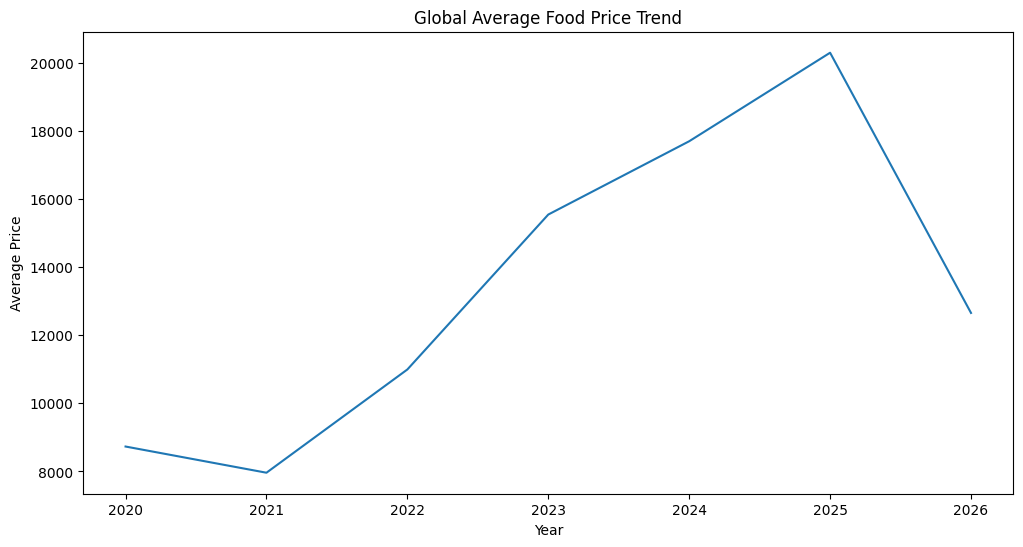

In [12]:
global_trend = df.groupby("year")["price"].mean()

plt.figure(figsize=(12,6))

global_trend.plot()

plt.title("Global Average Food Price Trend")

plt.xlabel("Year")

plt.ylabel("Average Price")

plt.show()

In [13]:
plt.savefig("../images/global_food_price_trend.png")

<Figure size 640x480 with 0 Axes>

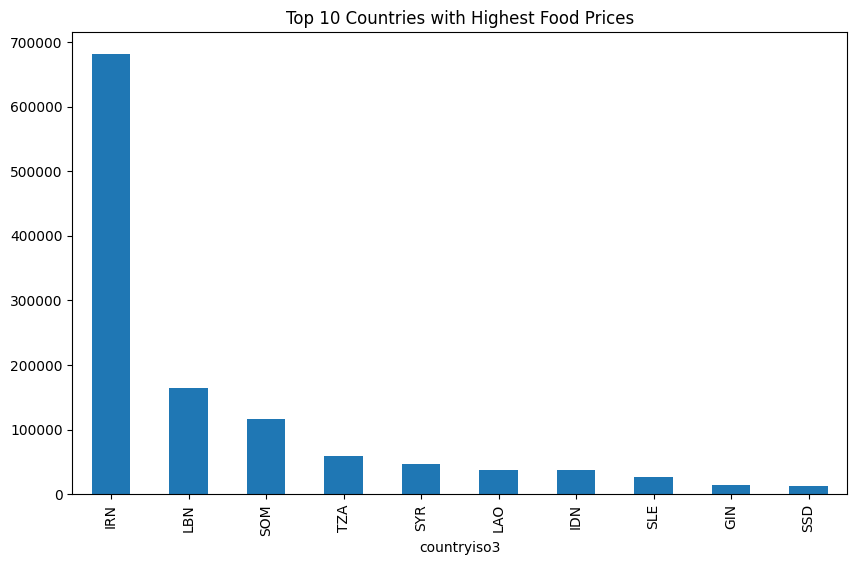

In [14]:
country_price = df.groupby("countryiso3")["price"].mean().sort_values(ascending=False)

top10 = country_price.head(10)

plt.figure(figsize=(10,6))

top10.plot(kind="bar")

plt.title("Top 10 Countries with Highest Food Prices")

plt.show()

In [15]:
commodity_price = df.groupby("commodity")["price"].mean().sort_values(ascending=False)

commodity_price.head(10)

commodity
Livestock (sheep, two-year-old male)    1.321663e+06
Livestock (Goat)                        4.884501e+05
Fuel (petrol-gasoline, 95 octane)       2.410270e+05
Millet (finger)                         1.627200e+05
Meat (beef, first quality)              1.301199e+05
Millet (bulrush)                        1.292667e+05
Fuel (gas, parallel market)             1.282565e+05
Livestock (camel)                       1.160610e+05
Lentils (green)                         1.127991e+05
Livestock (cattle)                      1.086028e+05
Name: price, dtype: float64

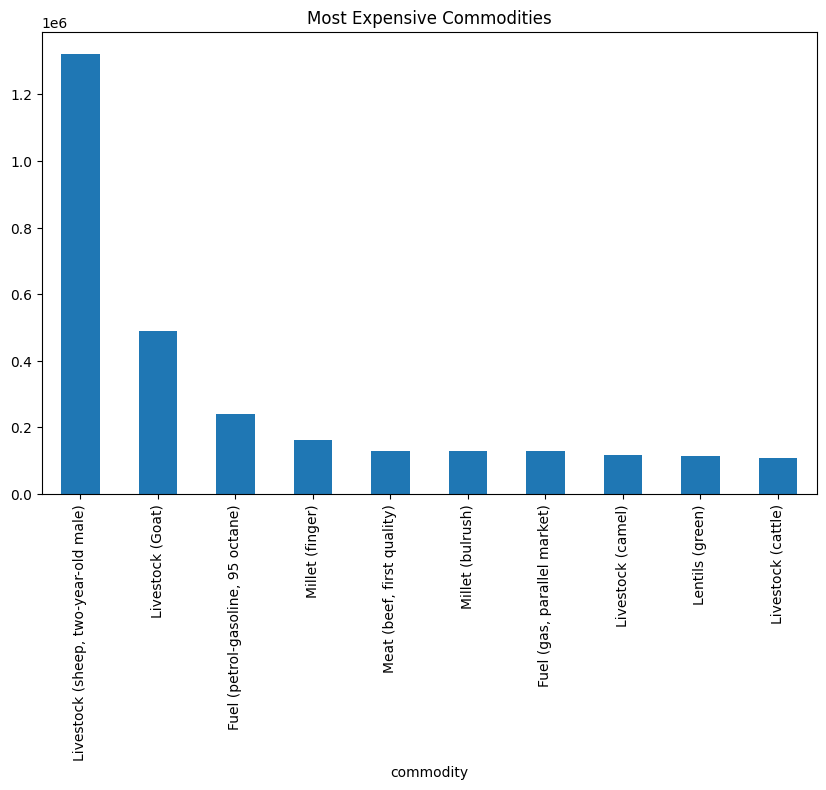

In [16]:
plt.figure(figsize=(10,6))

commodity_price.head(10).plot(kind="bar")

plt.title("Most Expensive Commodities")

plt.show()

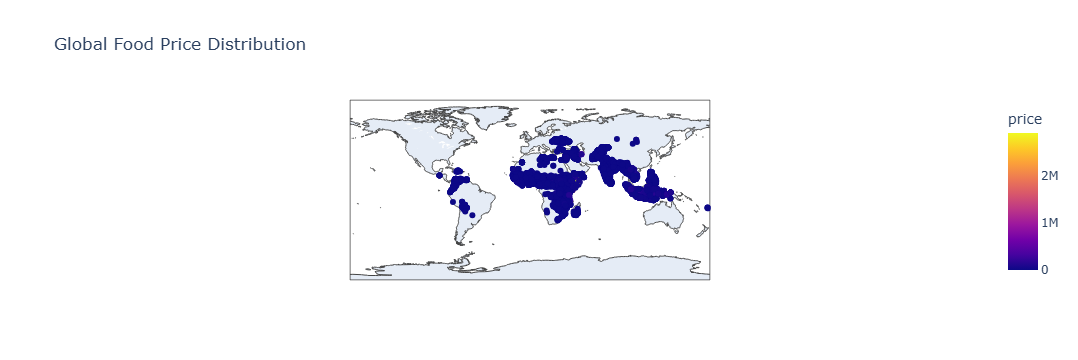

In [17]:
fig = px.scatter_geo(
    df.sample(5000),
    lat="latitude",
    lon="longitude",
    color="price",
    hover_name="commodity",
    title="Global Food Price Distribution"
)

fig.show()

In [18]:
df["price_change"] = df["price"].pct_change()

In [19]:
df.nlargest(10, "price_change")

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,year,month,price_change
934689,NGA,2022-09-15,Kaduna,Lere,Saminaka,1982,10.42,8.68,cereals and tubers,Gari (white),483,100 KG,aggregate,Wholesale,NGN,26133.33,61.04,2022,9,26132.330000
496565,KEN,2021-01-15,Central,Nyeri,Karatina (Nyeri),5670,-0.48,37.13,pulses and nuts,Beans (kidney),180,90 KG,actual,Wholesale,KES,7200.00,65.45,2021,1,25713.285714
248942,SYR,2020-01-15,Dar'a,Izra',Izr'a,2523,32.85,36.27,cereals and tubers,Rice,52,MT,actual,Wholesale,SYP,650000.00,1494.25,2020,1,18288.251548
1229189,KEN,2023-01-15,Central,Nyeri,Karatina (Nyeri),5670,-0.48,37.13,cereals and tubers,"Maize (white, dry)",440,90 KG,actual,Wholesale,KES,5337.00,43.12,2023,1,15696.058824
255860,SYR,2020-05-15,Quneitra,Quneitra,Khan Arnaba,1554,33.18,35.89,cereals and tubers,Bulgur,258,MT,aggregate,Wholesale,SYP,581944.45,1134.39,2020,5,13753.300402
278520,TZA,2020-01-15,Arusha,Arusha Urban,Arusha (urban),80,-3.37,36.68,cereals and tubers,Maize,51,100 KG,actual,Wholesale,TZS,92500.00,40.18,2020,1,13443.767442
255501,SYR,2020-05-15,Homs,Homs,Ekrema,1551,34.71,36.72,cereals and tubers,Bulgur,258,MT,aggregate,Wholesale,SYP,850000.00,1656.92,2020,5,13393.264103
253591,SYR,2020-04-15,Hama,Masyaf,Masyaf,1137,35.06,36.34,cereals and tubers,Bulgur,258,MT,aggregate,Wholesale,SYP,809399.99,1577.78,2020,4,12753.490860
253652,SYR,2020-04-15,Homs,Al Makhrim,Al Makhrim,2682,34.85,37.00,cereals and tubers,Bulgur,258,MT,aggregate,Wholesale,SYP,809399.99,1577.78,2020,4,12753.490860
253745,SYR,2020-04-15,Homs,Homs,Al Waer,1930,34.74,36.68,cereals and tubers,Bulgur,258,MT,aggregate,Wholesale,SYP,809399.99,1577.78,2020,4,12753.490860


In [20]:
volatility = df.groupby("commodity")["price"].std().sort_values(ascending=False)

volatility.head(10)

commodity
Livestock (sheep, two-year-old male)    1.418504e+06
Fuel (diesel)                           1.080818e+06
Livestock (Goat)                        9.366996e+05
Fuel (petrol-gasoline, 95 octane)       5.121078e+05
Peas (yellow, split)                    3.913768e+05
Lentils (green)                         3.653217e+05
Beans (kidney red)                      3.181699e+05
Rice (white)                            2.290079e+05
Meat (beef)                             2.054865e+05
Fuel (gas)                              1.764319e+05
Name: price, dtype: float64

In [21]:
X = df[["year","month"]]
y = df["price"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [23]:
model = RandomForestRegressor()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
predictions = model.predict(X_test)

In [25]:
mean_squared_error(y_test,predictions)

74626712110.95683

In [26]:
df.to_csv("../dashboard/processed_food_prices.csv", index=False)